# Assignment 6: Building Your First Neural Network

**Student Name:** [Baigali Nyamdulam]

**Date:** [03/12/2026]

---

## Assignment Overview

You'll build feedforward neural networks to classify human activities from sensor data. You'll experiment with different architectures, compare performance against Unit 7's PCA+Random Forest approach, and learn when neural networks justify their added complexity.

---

## Step 1: Import Libraries and Load Data

In [3]:
pip install pandas numpy matplotlib seaborn scikit-learn tensorflow

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ------------------------ --------------- 6.0/9.9 MB 30.8 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 25.7 MB/s  0:00:00
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -------------------------------------- - 7.9/8.1 MB 37.4 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 29.6 MB/s  0:00:00
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -------------------------------------- - 7.9/8.1 MB 40.4 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 31.3 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 26.7 MB/s  0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   -------------------------------------- - 6.8/7.0 MB 42.0 MB/s eta 0:00:01
   ---------------------------------------- 7.0/7.0

In [4]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✓ Libraries imported successfully")
print(f"TensorFlow version: {tf.__version__}")

✓ Libraries imported successfully
TensorFlow version: 2.21.0


In [7]:
# Load the Human Activity Recognition dataset
# TODO: Load train.csv and test.csv from the data folder
train_df = pd.read_csv('data/train.csv')  # Replace with pd.read_csv()
test_df = pd.read_csv('data/test.csv')   # Replace with pd.read_csv()

# TODO: Separate features from labels
# The 'Activity' column contains the labels (1-6)
X_train = train_df.drop('Activity', axis=1).values
y_train = train_df['Activity'].values
X_test = test_df.drop('Activity', axis=1).values
y_test = test_df['Activity'].values

# Encode string labels to integers (0-5)
# Neural networks need numerical labels
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

print("\n" + "="*80)
print("CHECKPOINT: Verify dataset loaded correctly")
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Number of features: {X_train.shape[1]}")
print(f"Number of activities: {len(np.unique(y_train))}")
print(f"Activity labels range: {y_train.min()} to {y_train.max()}")
print(f"Activity classes: {label_encoder.classes_}")
print("="*80)


CHECKPOINT: Verify dataset loaded correctly
Training set shape: (7352, 562)
Test set shape: (2947, 562)
Number of features: 562
Number of activities: 6
Activity labels range: 0 to 5
Activity classes: ['LAYING' 'SITTING' 'STANDING' 'WALKING' 'WALKING_DOWNSTAIRS'
 'WALKING_UPSTAIRS']


### Standardize Features

Neural networks learn best when features are normalized to similar scales

In [9]:
# TODO: Use StandardScaler to normalize features
# Fit on training data, transform both train and test

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Replace with scaled training data
X_test_scaled = scaler.fit_transform(X_test)   # Replace with scaled test data

print("\n" + "="*80)
print("CHECKPOINT: Features Standardized")
print(f"Mean of scaled features: {X_train_scaled.mean():.6f}")
print(f"Std of scaled features: {X_train_scaled.std():.6f}")
print("="*80)


CHECKPOINT: Features Standardized
Mean of scaled features: 0.000000
Std of scaled features: 1.000000


---
## Step 2: Build and Train Baseline Neural Network

### Create Baseline Architecture (1 Hidden Layer)

In [12]:
# TODO: Build a Sequential model with:
# - Input layer: Dense(64, activation='relu', input_shape=(562,))
# - Output layer: Dense(6, activation='softmax')

baseline_model = keras.Sequential([
    layers.Input(shape=(562,)),            # Input: 784 pixel values
    layers.Dense(64, activation='relu'),   # Hidden layer: 64 nodes with ReLU
    layers.Dense(6, activation='softmax') # Output: 10 classes with softmax
])  # Replace with your model

# TODO: Compile the model with:
# - optimizer='adam'
# - loss='sparse_categorical_crossentropy'
# - metrics=['accuracy']
baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
if baseline_model is not None:
    baseline_model.summary()
else:
    print("Model not created yet")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 64)             │        36,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,422 (142.27 KB)

 Trainable params: 36,422 (142.27 KB)

 Non-trainable params: 0 (0.00 B)

### Train Baseline Model

In [13]:
# TODO: Train the model for 20 epochs with validation_split=0.2
# Save the training history and training time

print("Training baseline model (1 hidden layer, 64 nodes)...")
start_time = time.time()

# Your training code here
baseline_history = baseline_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)  # Replace with model.fit() result

baseline_time = time.time() - start_time

# TODO: Evaluate on test set
baseline_test_loss, baseline_test_accuracy = baseline_model.evaluate(X_test, y_test, verbose=0)  # Replace with model.evaluate()

print("\n" + "="*80)
print("BASELINE MODEL RESULTS")
print("="*80)
print(f"Architecture: 1 hidden layer, 64 nodes")
print(f"Test accuracy: {baseline_test_accuracy if baseline_test_accuracy else 'Not calculated'}")
print(f"Training time: {baseline_time:.2f} seconds")
print("="*80)

Training baseline model (1 hidden layer, 64 nodes)...
Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7744 - loss: 0.6458 - val_accuracy: 0.9171 - val_loss: 0.3282
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9170 - loss: 0.2602 - val_accuracy: 0.9211 - val_loss: 0.2376
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9444 - loss: 0.1764 - val_accuracy: 0.9239 - val_loss: 0.2082
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9558 - loss: 0.1343 - val_accuracy: 0.9266 - val_loss: 0.1970
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9646 - loss: 0.1092 - val_accuracy: 0.9293 - val_loss: 0.1894
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9709 - loss: 0.0926 - val_accuracy: 0.9279 - val_loss: 0.1914
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9748 - loss: 0.0811 - val_accuracy: 0.9341 - val_loss: 0.1839
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/ste

---
## Step 3: Experiment with Network Depth (Number of Layers)

### Shallow Network (1 Layer) - Already Done Above

Baseline model = 1 hidden layer with 64 nodes

### Medium Network (2 Layers)

In [25]:
# TODO: Build model with 2 hidden layers:
# - Dense(128, activation='relu', input_shape=(562,))
# - Dense(64, activation='relu')
# - Dense(6, activation='softmax')

medium_model = keras.Sequential([
    layers.Input(shape=(562,)),
    layers.Dense(128, activation='relu'),  # First hidden layer
    layers.Dense(64, activation='relu'),   # Second hidden layer
    layers.Dense(6, activation='softmax')
]) # Replace with your model

# TODO: Compile with same settings as baseline
medium_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# TODO: Train for 20 epochs with validation_split=0.2
print("Training medium network (2 hidden layers)...")
medium_history = medium_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)  # Replace with model.fit() result

# TODO: Evaluate on test set
medium_test_loss, medium_test_accuracy = medium_model.evaluate(X_test, y_test, verbose=0)

print(f"\nMedium network test accuracy: {medium_test_accuracy if medium_test_accuracy else 'Not calculated'}")

Training medium network (2 hidden layers)...

Medium network test accuracy: 0.9365456104278564


### Deep Network (3 Layers)

In [16]:
# TODO: Build model with 3 hidden layers:
# - Dense(128, activation='relu', input_shape=(562,))
# - Dense(64, activation='relu')
# - Dense(32, activation='relu')
# - Dense(6, activation='softmax')

deep_model = keras.Sequential([
    layers.Input(shape=(562,)),
    layers.Dense(128, activation='relu'),  # First hidden layer
    layers.Dense(64, activation='relu'),   # Second hidden layer
    layers.Dense(32, activation='relu'),   # Third hidden layer
    layers.Dense(6, activation='softmax')
])  # Replace with your model

# TODO: Compile with same settings

deep_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# TODO: Train for 20 epochs with validation_split=0.2
print("Training deep network (3 hidden layers)...")
deep_history = deep_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)  # Replace with model.fit() result

# TODO: Evaluate on test set
deep_test_loss, deep_test_accuracy = deep_model.evaluate(X_test, y_test, verbose=0)

print(f"\nDeep network test accuracy: {deep_test_accuracy if deep_test_accuracy else 'Not calculated'}")

Training deep network (3 hidden layers)...

Deep network test accuracy: 0.9239904880523682


### Compare Depth Experiments

In [17]:
# TODO: Create comparison of depth experiments
depth_results = pd.DataFrame({
    'Architecture': ['1 Layer (64)', '2 Layers (128, 64)', '3 Layers (128, 64, 32)'],
    'Test Accuracy': [baseline_test_accuracy, medium_test_accuracy, deep_test_accuracy]
})

print("\n" + "="*80)
print("DEPTH EXPERIMENT RESULTS")
print("="*80)
print(depth_results.to_string(index=False))
print("="*80)


DEPTH EXPERIMENT RESULTS
          Architecture  Test Accuracy
          1 Layer (64)       0.929420
    2 Layers (128, 64)       0.932474
3 Layers (128, 64, 32)       0.923990


### Reflection on Network Depth
In the Markdown cell below, write 2-3 sentences that answer the following questions: 
- How does adding more layers affect performance? 
- At what point do you see diminishing returns?

[The performance didn't change as much with the addition of layers. In fact, it went down by 0.009 when the 3rd layer was added. Also, the performance increase that came with the 2nd layer wasn't even much as it was around 0.003.]

---
## Step 4: Experiment with Network Width (Nodes Per Layer)

### Narrow Network (2 Layers, 32 Nodes Each)

In [24]:
# TODO: Build model with 2 layers of 32 nodes each
# - Dense(32, activation='relu', input_shape=(562,))
# - Dense(32, activation='relu')
# - Dense(6, activation='softmax')

narrow_model = keras.Sequential([
    layers.Input(shape=(562,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(6, activation='softmax')
])# Replace with your model

# TODO: Compile  with the same settings
narrow_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# TODO: Train for 20 epochs
print("Training narrow network (2 layers, 32 nodes each)...")
narrow_history = narrow_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

# TODO: Evaluate
narrow_test_loss, narrow_test_accuracy = narrow_model.evaluate(X_test, y_test, verbose=0)

print(f"\nNarrow network test accuracy: {narrow_test_accuracy if narrow_test_accuracy else 'Not calculated'}")

Training narrow network (2 layers, 32 nodes each)...

Narrow network test accuracy: 0.9290804266929626


### Medium Width Network (2 Layers, 64 Nodes Each)

In [21]:
# TODO: Build model with 2 layers of 64 nodes each
medium_width_model = keras.Sequential([
    layers.Input(shape=(562,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(6, activation='softmax')
])

# TODO: Compile  with the same settings
medium_width_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# TODO: Train for 20 epochs and 64 nodes
print("Training medium-width network (2 layers, 64 nodes each)...")
medium_width_history = medium_width_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

# TODO: Evaluate
medium_width_test_loss, medium_width_test_accuracy = medium_width_model.evaluate(X_test, y_test, verbose=0)

print(f"\nMedium-width network test accuracy: {medium_width_test_accuracy if medium_width_test_accuracy else 'Not calculated'}")

Training medium-width network (2 layers, 64 nodes each)...

Medium-width network test accuracy: 0.92840176820755


### Wide Network (2 Layers, 128 Nodes Each)

In [22]:
# TODO: Build model with 2 layers of 128 nodes each
wide_model = keras.Sequential([
    layers.Input(shape=(562,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(6, activation='softmax')
])

# TODO: Compile  with the same settings
wide_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# TODO: Train the model
print("Training wide network (2 layers, 128 nodes each)...")
wide_history = wide_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

# TODO: Evaluate
wide_test_loss, wide_test_accuracy = wide_model.evaluate(X_test, y_test, verbose=0)

print(f"\nWide network test accuracy: {wide_test_accuracy if wide_test_accuracy else 'Not calculated'}")

Training wide network (2 layers, 128 nodes each)...

Wide network test accuracy: 0.92840176820755


### Compare Width Experiments

In [23]:
# TODO: Create comparison of width experiments
width_results = pd.DataFrame({
    'Architecture': ['2 Layers (32 each)', '2 Layers (64 each)', '2 Layers (128 each)'],
    'Test Accuracy': [narrow_test_accuracy, medium_width_test_accuracy, wide_test_accuracy]
})

print("\n" + "="*80)
print("WIDTH EXPERIMENT RESULTS")
print("="*80)
print(width_results.to_string(index=False))
print("="*80)


WIDTH EXPERIMENT RESULTS
       Architecture  Test Accuracy
 2 Layers (32 each)       0.929080
 2 Layers (64 each)       0.928402
2 Layers (128 each)       0.928402


### Reflection on Network Width

In the Markdown cell below, write 2-3 sentences that answer the following questions: 
- How does increasing nodes per layer affect performance? 
- Is there a point where adding more nodes doesn't help?

[The performance generally decreased but there weren't any difference between 64 and 128 nodes. In our case, adding more nodes per layer doesn't help at all. Also, even though we didn't exactly capture the time that took each of these variations to run, I did notice that 128 nodes version ran much longer than the others. So, adding more nodes, at least in our case, is costly and performs worse.]

---
## Step 5: Train Best Architecture and Visualize Learning

### Identify and Train Best Architecture

In [30]:
# TODO: Based on your experiments above, build your best-performing architecture
# Train it for 30 epochs (longer training often improves performance)

best_model = keras.Sequential([
    layers.Input(shape=(562,)),
    layers.Dense(128, activation='relu'),  # First hidden layer
    layers.Dense(64, activation='relu'),   # Second hidden layer
    layers.Dense(6, activation='softmax')
]) # Replace with your best architecture

# TODO: Compile the model

best_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("Training best model for 30 epochs...")
start_time = time.time()

# TODO: Train for 30 epochs with validation_split=0.2
best_history = best_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)  # Replace with model.fit() result

# TODO: Evaluate on test set

best_time = time.time() - start_time

# TODO: Evaluate on test set
best_test_loss, best_test_accuracy = best_model.evaluate(X_test, y_test, verbose=0)

print("\n" + "="*80)
print("BEST MODEL RESULTS")
print("="*80)
print(f"Architecture: [Medium Network with 2 layers]")
print(f"Test accuracy: {best_test_accuracy if best_test_accuracy else 'Not calculated'}")
print(f"Training time: {best_time:.2f} seconds")
print("="*80)

Training best model for 30 epochs...

BEST MODEL RESULTS
Architecture: [Medium Network with 2 layers]
Test accuracy: 0.9345096945762634
Training time: 37.49 seconds


### Visualize Training Progress - Accuracy

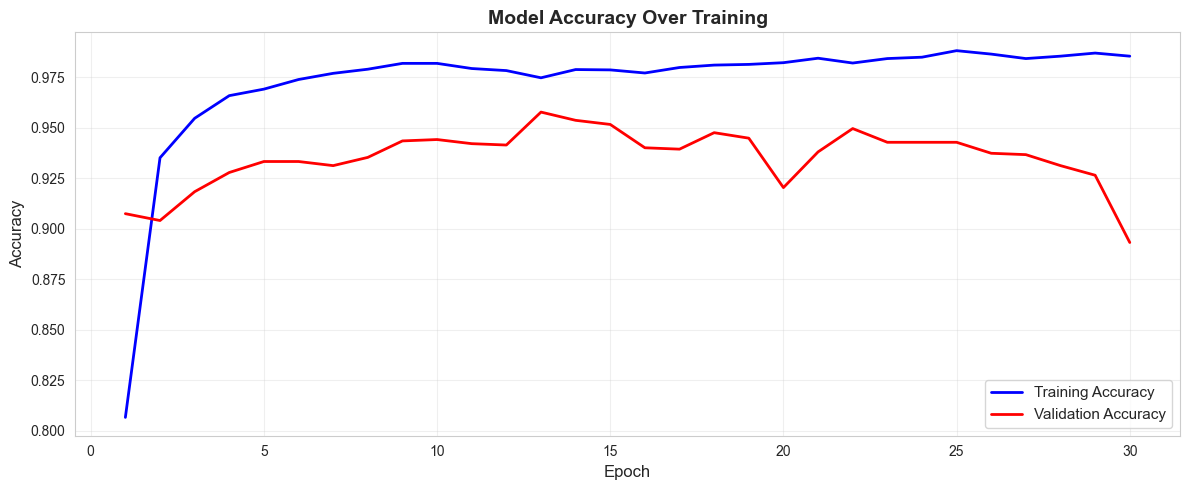

In [27]:
# TODO: Plot training accuracy vs validation accuracy over epochs
# Use best_history.history['accuracy'] and best_history.history['val_accuracy']
train_accuracy = best_history.history['accuracy']
val_accuracy = best_history.history['val_accuracy']
epochs = range(1, len(train_accuracy) + 1)
if best_history is not None:
    plt.figure(figsize=(12, 5))
    plt.plot(epochs, train_accuracy, 'b-', linewidth=2, label='Training Accuracy')
    plt.plot(epochs, val_accuracy, 'r-', linewidth=2, label='Validation Accuracy')
    plt.title('Model Accuracy Over Training', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.legend(loc='lower right', fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Train best model first to visualize results")

### Visualize Training Progress - Loss

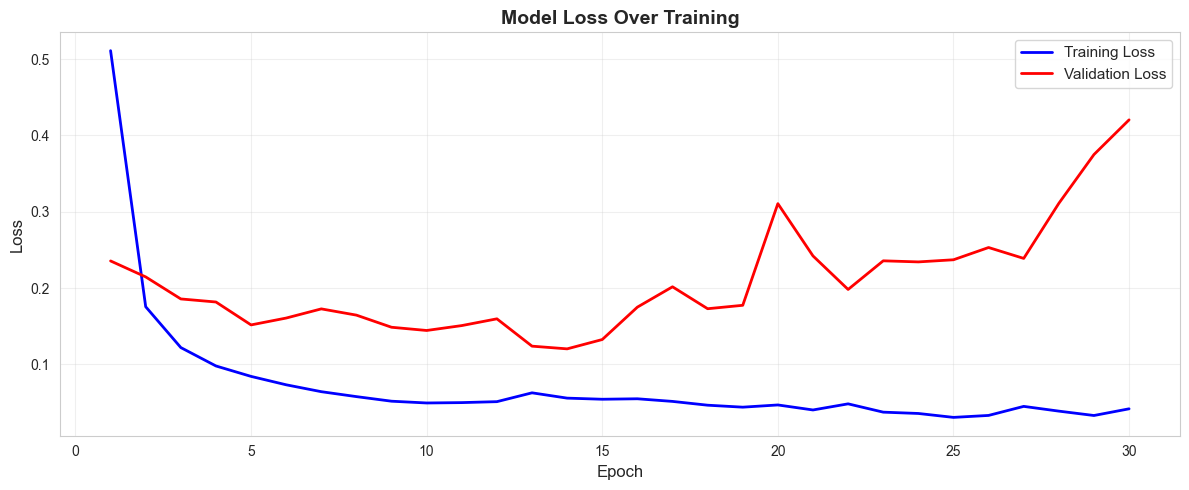

In [28]:
# TODO: Plot training loss vs validation loss over epochs
# Use best_history.history['loss'] and best_history.history['val_loss']
train_loss = best_history.history['loss']
val_loss = best_history.history['val_loss']
epochs = range(1, len(train_accuracy) + 1)
if best_history is not None:
    plt.figure(figsize=(12, 5))
    plt.plot(epochs, train_loss, 'b-', linewidth=2, label='Training Loss')
    plt.plot(epochs, val_loss, 'r-', linewidth=2, label='Validation Loss')
    plt.title('Model Loss Over Training', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend(loc='upper right', fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Train best model first to visualize results")

---
## Step 6: Compare Against Unit 7 PCA + Random Forest

In [31]:
# TODO: Enter your Unit 7 PCA+Random Forest results here
# You should have recorded these in Unit 7
unit7_pca_rf_accuracy = 0.863590  # Replace with your Unit 7 test accuracy
unit7_pca_rf_time = 1.069139  # Replace with your Unit 7 training time (if you have it)

# Create comparison table
comparison = pd.DataFrame({
    'Model': [
        'Baseline NN (1 layer, 64 nodes)',
        'Best NN (Your Architecture)',
        'Unit 7: PCA + Random Forest'
    ],
    'Features/Layers': [
        '1 hidden layer',
        '[Medium Network with 2 layers]',
        '30 PCA components'
    ],
    'Test Accuracy': [
        baseline_test_accuracy,
        best_test_accuracy,
        unit7_pca_rf_accuracy
    ],
    'Training Time': [
        f"{baseline_time:.2f}s" if baseline_time else 'N/A',
        f"{best_time:.2f}s" if best_time else 'N/A',
        f"{unit7_pca_rf_time:.2f}s" if unit7_pca_rf_time else 'N/A'
    ]
})

print("\n" + "="*80)
print("MODEL COMPARISON: NEURAL NETWORKS VS UNIT 7")
print("="*80)
print(comparison.to_string(index=False))
print("="*80)


MODEL COMPARISON: NEURAL NETWORKS VS UNIT 7
                          Model                Features/Layers  Test Accuracy Training Time
Baseline NN (1 layer, 64 nodes)                 1 hidden layer        0.92942        13.18s
    Best NN (Your Architecture) [Medium Network with 2 layers]        0.93451        37.49s
    Unit 7: PCA + Random Forest              30 PCA components        0.86359         1.07s


### Reflection on Neural Network vs PCA+Random Forest
In the Markdown cell, write 2-3 sentences that answer the following questions:
- How does your best neural network compare to PCA+Random Forest?
- Did the neural network's ability to learn its own features from raw sensor data lead to better performance than manually engineering features with PCA? (2-3 sentences)

[The model I chose as my best is really computationally expensive. It definitely performs the best, but compared to the basline model its accuracy difference is close to being negligible. On top of that, taking 24 seconds more than the baseline model is atrocious.]

---
## Step 7: Reflect on When to Use Neural Networks

### When to Use Neural Networks vs Simpler Models

In the Markdown cell below, write 3-4 sentences addressing the following: 
- Based on your results and what you learned in the resources, when should you use neural networks versus simpler models like random forests? Consider factors like data type (sensor data, images, text vs tabular business data), dataset size, interpretability needs, and performance requirements. 
- Give at least one example of when you'd choose neural networks and one example of when you'd choose random forests

[If the performance difference is close to being negligible, the added computation expense (in terms of time) is not worth because it might actually take twice as much or even more time to fully run the model for an "improvement" that is close to being 0. Considering the actual best model from neural network which is the 1 layer and 64 nodes model (in this specific case), we see about 0.06 improvement in terms of performance and 12 more seconds in run time compared to the random forest + PCA model. If we have to analyze small sets of data at all times and being efficient is important, the random forest + PCA model wins the race. However, if accuracy is more important and we have enough data to train the model to begin with, the neural network model is better. Of course neural network works the best for images, sensor data, and text because it is able to make sense of a huge mess, but simpler tabular data should almost exclusively be handled by random forest + PCA because of run time and efficiency. Besides, neural network is not going to work well if it doesn't have enough data train on. If we have ginormous amount of data to train on, the accuracy improvement neural network brings is probably going to be worth as it can handle complex relationships. Neural Network Example: Sorting through images, PCA+Random Forest Example: Credit risk evaluation]

---
## Step 8: Submit Your Work

Before submitting:
1. Make sure all code cells run without errors
2. Verify you have:
   - Baseline neural network trained and evaluated
   - At least 3 depth experiments (1, 2, 3 layers)
   - At least 3 width experiments (32, 64, 128 nodes)
   - Best model trained for 30 epochs with accuracy and loss plots
   - Comparison table with baseline NN, best NN, and Unit 7 PCA+RF
   - All reflection questions answered (2-3 or 3-4 sentences each)
3. Check that all visualizations display correctly

Then push to GitHub:
```bash
git add .
git commit -m 'completed neural networks assignment'
git push
```

Submit your GitHub repository link on the course platform.